This notebook aims to analyze Netflix's content catalog to understand their global production strategy and audience targeting through age ratings. The insights generated here serve as the foundation for a high-level Tableau Treemap visualization.

# 🎬 Netflix Content Strategy: Genre & Rating Analysis

## 📌 Table of Contents
1. [Introduction & Objective](#1)
2. [Data Loading & Library Imports](#2)
3. [Data Inspection & Health Check](#3)
4. [Data Cleaning (Handling Missing Values)](#4)
5. [Exploratory Data Analysis (EDA)](#5)
    - 5.1 [Movies vs TV Shows Distribution](#5.1)
    - 5.2 [Global Content Production (Top 10 Countries)](#5.2)
    - 5.3 [Content Rating Analysis (The Business Logic)](#5.3)
    - 5.4 [Content Growth Trend (2000-2021)](#5.4)
6. [Key Insights & Strategic Recommendations](#6)
7. [Connection to Tableau Dashboard](#7)

# <a id="1"></a> 1. Introduction & Objective

The entertainment industry is undergoing a massive shift towards digital streaming. This notebook performs an **Exploratory Data Analysis (EDA)** on the Netflix Movies and TV Shows dataset. 

**The Objective:** 
To provide actionable insights for C-level executives regarding Netflix's global content strategy, audience targeting through age ratings, and the growth of its library over the last two decades.

# <a id="2"></a> 2. Data Loading & Library Imports
We begin by importing necessary libraries for data manipulation and visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Path ko apne dataset ke mutabiq check kar lena
path = '/kaggle/input/datasets/obaidhere/netflix-content-strategy-genre-and-rating-analysis/netflix_titles.csv' 
df = pd.read_csv(path)
print("Data successfully loaded!")

Data successfully loaded!


# <a id="3"></a> 3. Data Inspection & Health Check
Understanding the structure of our data (rows, columns, and types).

In [2]:
print("Dataset Shape:", df.shape)
display(df.head())
display(df.info())

Dataset Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


None

In [3]:
print("Dataset Shape:", df.shape)
display(df.head())
display(df.info())

Dataset Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


None

# <a id="4"></a> 4. Data Cleaning
We will fill missing 'Director' and 'Cast' entries with **"Unknown"**.

In [4]:
# Missing values check
print("Missing values before cleaning:\n", df.isnull().sum())

# Filling missing values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('United States') # Default to US for analysis

print("\nMissing values after cleaning:\n", df.isnull().sum())

Missing values before cleaning:
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Missing values after cleaning:
 show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           4
duration         3
listed_in        0
description      0
dtype: int64


# <a id="5.1"></a> 5.1 Movies vs TV Shows Distribution
Is Netflix a movie hub or a series powerhouse?

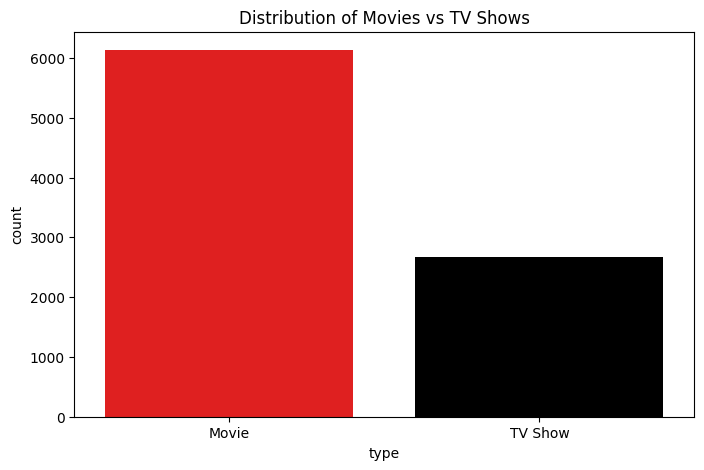

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(8,5))
# hue='type' aur legend=False ka izafa kiya
sns.countplot(x='type', data=df, hue='type', palette=['red', 'black'], legend=False)
plt.title('Distribution of Movies vs TV Shows')
plt.show()

print(df['type'].value_counts())

# <a id="5.2"></a> 5.2 Global Content Production
Which countries are the major hubs for Netflix content?

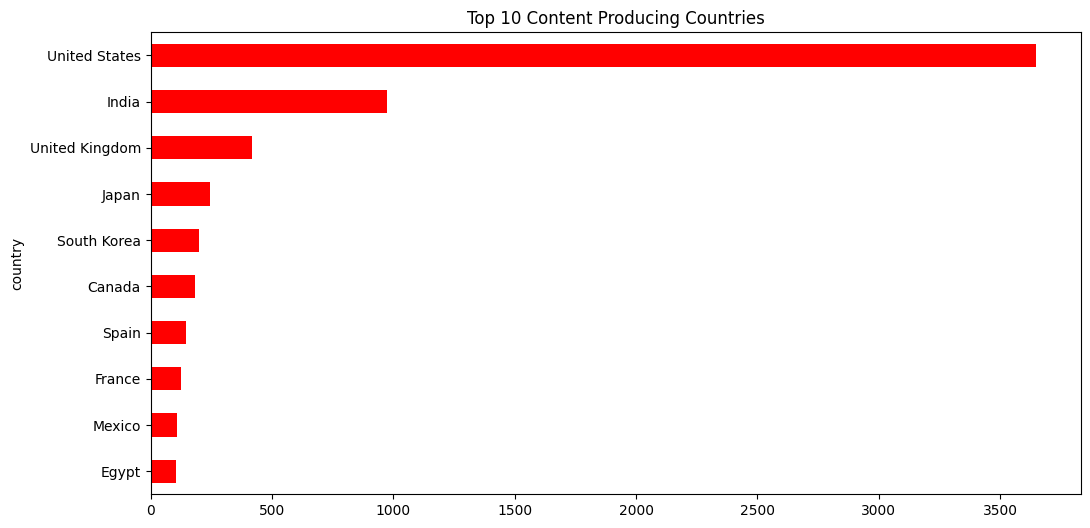

In [6]:
plt.figure(figsize=(12,6))
df['country'].value_counts().head(10).plot(kind='barh', color='red')
plt.title('Top 10 Content Producing Countries')
plt.gca().invert_yaxis() # Top country oper lane ke liye
plt.show()

# <a id="5.3"></a> 5.3 Content Rating Analysis
This analysis directly informs our **Tableau Treemap**.

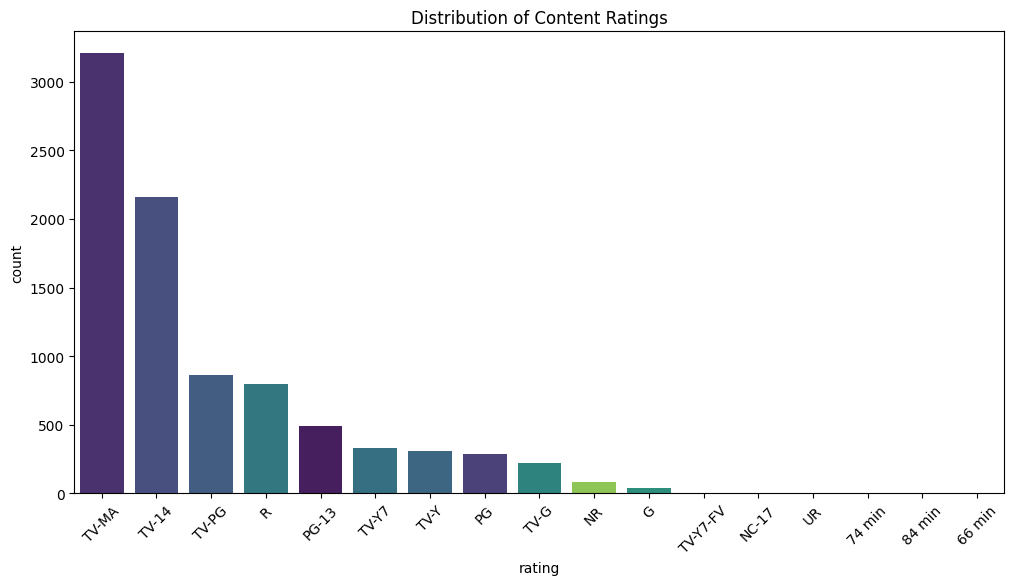

Top 5 Ratings:
 rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
Name: count, dtype: int64


In [7]:
plt.figure(figsize=(12,6))
# hue='rating' aur legend=False ka izafa kiya
sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, hue='rating', palette='viridis', legend=False)
plt.title('Distribution of Content Ratings')
plt.xticks(rotation=45)
plt.show()

print("Top 5 Ratings:\n", df['rating'].value_counts().head(5))

# <a id="5.4"></a> 5.4 Content Growth Trend (2000-2021)
How has Netflix expanded its library over the years?

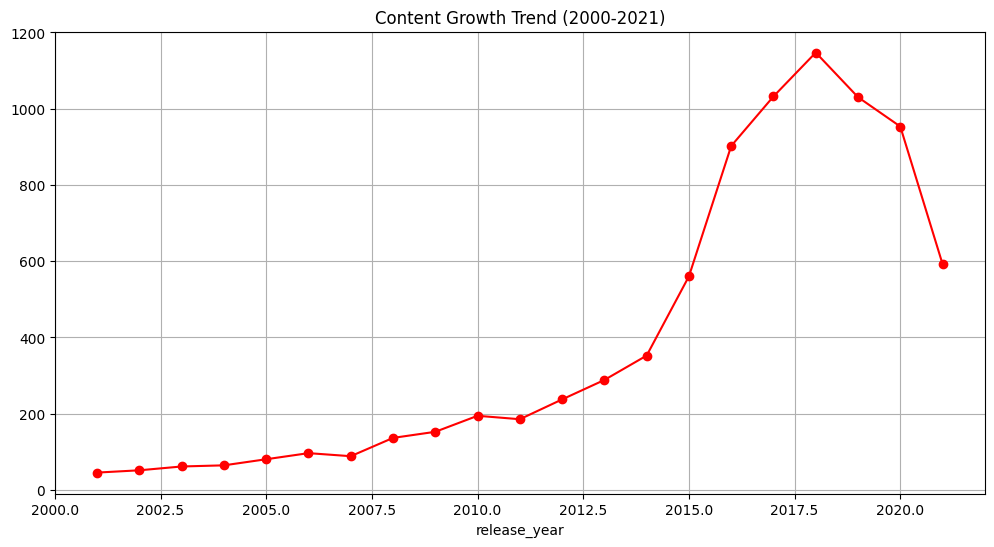

In [8]:
plt.figure(figsize=(12,6))
df[df['release_year'] > 2000]['release_year'].value_counts().sort_index().plot(kind='line', marker='o', color='red')
plt.title('Content Growth Trend (2000-2021)')
plt.grid(True)
plt.show()

# <a id="6"></a> 6. Key Insights & Strategic Recommendations
1. **Target Audience:** TV-MA (Mature) is the leading category.
2. **Growth:** Huge release spike after 2015.
3. **Regional Focus:** USA and India are key production markets.

# <a id="7"></a> 7. Connection to Tableau Dashboard
These insights are visualized in an interactive **Treemap Dashboard in Tableau**.

### 💡 Final Strategic Insights:
**Mature Content Focus:** Netflix's heavy investment in 'TV-MA' content indicates a clear focus on adult audiences.
**Global Expansion:** While the USA leads, countries like India and UK are becoming major content hubs.
**Movie Dominance:** Movies still outnumber TV Shows, but the growth rate of TV Shows is increasing yearly.
